Niedokończona koncepcja robienia "binary searchu" na całym zbiorze za pomocą wielu sieci neuronowych. WYniki były mało obiecujące - pomysł zarzucono 

In [1]:
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from jordanutils import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


rng = np.random.default_rng(seed=123)

In [8]:
d = 5
dataset_size = 100_000

labels_manager = LabelsManager([1, 2], [3, 4], dataset_size=dataset_size)
X, y = generate_testset(d, labels_manager, mode="random")
# block size ==1 vs. >=2

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=123
)

X_train = X_train.astype(np.float32)
y_train = np.array(y_train, dtype=np.int32)
y_val = np.array(y_val, dtype=np.int32)

model = tf.keras.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(d, d)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(d),
    ]
)

model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=3, restore_best_weights=True
)

model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
)


Epoch 1/50


c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5000/5000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.6365 - loss: 0.6724 - val_accuracy: 0.7125 - val_loss: 0.5537
Epoch 2/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7183 - loss: 0.5400 - val_accuracy: 0.7484 - val_loss: 0.5068
Epoch 3/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7491 - loss: 0.4861 - val_accuracy: 0.7544 - val_loss: 0.4888
Epoch 4/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7700 - loss: 0.4562 - val_accuracy: 0.7702 - val_loss: 0.4600
Epoch 5/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7796 - loss: 0.4394 - val_accuracy: 0.7793 - val_loss: 0.4502
Epoch 6/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7931 - loss: 0.4192 - val_accuracy: 0.7872 - val_loss: 0.4384
Epoch 7/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7922 - loss: 0.4151 - val_accuracy: 0.7896 - val_loss: 0.4354
Epoch 8/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7973 - loss: 0.4099 - val_accura

In [9]:
labels_manager.dataset_size = 1000
X_test, y_test = generate_testset(d, labels_manager, mode="ortho")


y_predicted = model.predict(X_test)
y_predicted = np.argmax(y_predicted, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


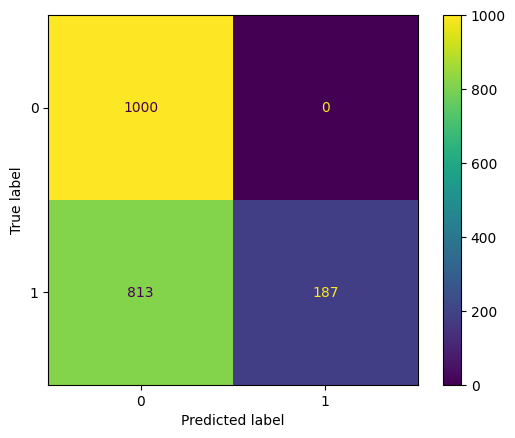

              precision    recall  f1-score   support

           0       0.55      1.00      0.71      1000
           1       1.00      0.19      0.32      1000

    accuracy                           0.59      2000
   macro avg       0.78      0.59      0.51      2000
weighted avg       0.78      0.59      0.51      2000



In [11]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

cm = confusion_matrix(y_test, y_predicted)
ConfusionMatrixDisplay(cm).plot()
plt.show()

print(classification_report(y_test, y_predicted))

In [ ]:
from typing import List, Tuple
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

class Model:
    """
    Build a binary-search-like decision list over labels 0..n-1.

    Attributes
    ----------
    n : int
        Number of classes.
    decisions : List[Tuple[List[int], List[int]]]
        List of binary decisions. Each element is (left_list, right_list).
        The first element is always ([0], [1,2,...,n-1]).
    """

    def __init__(self, n: int):
        if n < 1:
            raise ValueError("n must be >= 1")
        self.n = int(n)
        self.decisions: List[Tuple[List[int], List[int]]] = self._build_decisions()

    def _build_decisions(self) -> List[Tuple[List[int], List[int]]]:
        if self.n == 1:
            return []
        labels = list(range(self.n))
        decisions: List[Tuple[List[int], List[int]]] = []

        # root decision: [0] vs [1..n-1]
        root_left = [labels[0]]
        root_right = labels[1:]
        decisions.append((root_left.copy(), root_right.copy()))

        # recursive splitting for any subset with size > 1
        def rec(sub: List[int]):
            if len(sub) <= 1:
                return
            m = len(sub)
            mid = m // 2  # floor division
            left = sub[:mid]
            right = sub[mid:]
            decisions.append((left.copy(), right.copy()))
            rec(left)
            rec(right)

        # start recursion on right-part of root
        rec(root_right)
        return decisions

    def __repr__(self):
        return f"Model(n={self.n}, decisions={self.decisions})"


    def train_decision_models(self, dataset_size=100_000, epochs=50, batch_size=256):
        """
        For each decision in model_obj.decisions:
        - Create LabelsManager
        - Generate dataset with generate_testset
        - Train a small NN
        - Return a dict {decision: trained_model}
        
        Parameters
        ----------
        d : int
            Dimension of input matrix (n x n).
        model_obj : Model
            The Model object containing .decisions
        dataset_size : int
            Number of samples for generate_testset.
        epochs : int
            Training epochs.
        batch_size : int
            Batch size for training.
        """
        self.decision_models = {}

        for left, right in self.decisions:
            print(f"\n=== Training decision {left} vs {right} ===")

            # Step 1: LabelsManager and dataset
            labels_manager = LabelsManager(left, right, dataset_size=dataset_size)
            X, y = generate_testset(self.n, labels_manager, mode="random")

            X_train, X_val, y_train, y_val = train_test_split(
                X, y, test_size=0.2, stratify=y, random_state=123
            )
            X_train = X_train.astype(np.float32)
            X_val = X_val.astype(np.float32)
            y_train = np.array(y_train, dtype=np.int32)
            y_val = np.array(y_val, dtype=np.int32)

            # Step 2: NN definition
            model = tf.keras.Sequential([
                tf.keras.layers.Flatten(input_shape=(self.n, self.n)),
                tf.keras.layers.Dense(128, activation="relu"),
                tf.keras.layers.Dense(128, activation="relu"),
                tf.keras.layers.Dense(128, activation="relu"),
                tf.keras.layers.Dense(128, activation="relu"),
                tf.keras.layers.Dense(128, activation="relu"),
                tf.keras.layers.Dense(128, activation="relu"),
                tf.keras.layers.Dense(128, activation="relu"),
                tf.keras.layers.Dense(128, activation="relu"),
                tf.keras.layers.Dense(128, activation="relu"),
                tf.keras.layers.Dense(2)   # binary decision (left vs right)
            ])

            model.compile(
                optimizer="adam",
                loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=["accuracy"],
            )

            # Step 3: training with early stopping
            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor="val_accuracy", patience=3, restore_best_weights=True
            )

            model.fit(
                X_train,
                y_train,
                epochs=epochs,
                batch_size=batch_size,
                validation_data=(X_val, y_val),
                callbacks=[early_stop],
                verbose=2
            )

            # Store the trained model
            self.decision_models[(tuple(left), tuple(right))] = model
    
    def validate_decision_model(self, decision, dataset_size: int = 1000):
        """
        Validate one trained decision model on a small random test set.

        Parameters
        ----------
        decision : Tuple[List[int], List[int]]
            The (left, right) split defining this binary decision.
        dataset_size : int
            How many samples to generate for validation.

        Returns
        -------
        (y_true, y_pred) : Tuple[List[int], List[int]]
            True labels and predicted labels.
        """
        trained_model = self.decision_models[decision]
        left, right = decision
        labels_manager = LabelsManager(list(left), list(right), dataset_size=dataset_size)

        # Generate small test set
        X_test, y_true = generate_testset(self.n, labels_manager, mode="random")
        X_test = X_test.astype(np.float32)
        y_true = np.array(y_true, dtype=np.int32)

        # Run model predictions
        logits = trained_model.predict(X_test, verbose=0)
        y_pred = np.argmax(logits, axis=1)

        return y_true.tolist(), y_pred.tolist()
    
    def predict(self, x: np.ndarray) -> int:
        """
        Predict final class for one matrix x (shape (n,n)).
        Requires self.trained_models filled with trained Keras models.
        """
        # walk down from root
        current_set = list(range(self.n))
        subset = current_set

        # special: root is always decision [0] vs [1..n-1]
        decision = self.decisions[0]
        model = self.decision_models[(tuple(decision[0]), tuple(decision[1]))]

        logits = model.predict(x[np.newaxis, ...].astype(np.float32), verbose=0)
        pred_side = np.argmax(logits, axis=1)[0]  # 0=left, 1=right
        subset = decision[pred_side]

        # keep splitting until 1 label remains
        while len(subset) > 1:
            # find corresponding decision for this subset
            found = None
            for dec in self.decisions:
                left, right = dec
                if left + right == subset:  # exact match
                    found = dec
                    break
            if found is None:
                raise RuntimeError(f"No decision found for subset {subset}")

            model = self.decision_models[(tuple(found[0]), tuple(found[1]))]
            logits = model.predict(x[np.newaxis, ...].astype(np.float32), verbose=0)
            pred_side = np.argmax(logits, axis=1)[0]
            subset = found[pred_side]

        return subset[0]  # only one label remains

    def full_validation(self, dataset_size: int = 1000, mode="random"):
        """
        Validate the full Model on a dataset covering all classes.
        
        Parameters
        ----------
        d : int
            Input matrix dimension.
        dataset_size : int
            Number of samples per decision group for test.
        mode : str
            Passed to generate_testset, e.g., 'random'.
        
        Returns
        -------
        (y_true, y_pred) : Tuple[List[int], List[int]]
            True labels and predicted labels.
        """
        y_true = []
        y_pred = []

        # For simplicity, generate dataset per decision and merge
        labels_manager = LabelsManager(*[[i] for i in range(self.n)], dataset_size=dataset_size)
        X, y = generate_testset(self.n, labels_manager, mode=mode)
        for xi, yi in zip(X, y):
            y_true.append(yi)
            y_pred.append(self.predict(xi))

        return y_true, y_pred


In [5]:
m = Model(5)
print(m.decisions)
m.train_decision_models()

[([0], [1, 2, 3, 4]), ([1, 2], [3, 4]), ([1], [2]), ([3], [4])]

=== Training decision [0] vs [1, 2, 3, 4] ===
Epoch 1/50


c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


625/625 - 5s - 8ms/step - accuracy: 0.9936 - loss: 0.0167 - val_accuracy: 1.0000 - val_loss: 1.7564e-04
Epoch 2/50
625/625 - 3s - 5ms/step - accuracy: 1.0000 - loss: 3.2948e-04 - val_accuracy: 1.0000 - val_loss: 1.6414e-06
Epoch 3/50
625/625 - 3s - 4ms/step - accuracy: 1.0000 - loss: 9.8428e-05 - val_accuracy: 1.0000 - val_loss: 1.3457e-04
Epoch 4/50
625/625 - 3s - 5ms/step - accuracy: 1.0000 - loss: 1.4317e-04 - val_accuracy: 1.0000 - val_loss: 6.5634e-07
Epoch 5/50
625/625 - 3s - 4ms/step - accuracy: 1.0000 - loss: 1.8662e-06 - val_accuracy: 1.0000 - val_loss: 7.1526e-07

=== Training decision [1, 2] vs [3, 4] ===
Epoch 1/50


c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


625/625 - 5s - 8ms/step - accuracy: 0.6645 - loss: 0.6017 - val_accuracy: 0.6941 - val_loss: 0.5533
Epoch 2/50
625/625 - 3s - 4ms/step - accuracy: 0.7219 - loss: 0.5311 - val_accuracy: 0.7123 - val_loss: 0.5324
Epoch 3/50
625/625 - 3s - 4ms/step - accuracy: 0.7492 - loss: 0.4896 - val_accuracy: 0.7653 - val_loss: 0.4723
Epoch 4/50
625/625 - 3s - 5ms/step - accuracy: 0.7730 - loss: 0.4555 - val_accuracy: 0.7694 - val_loss: 0.4636
Epoch 5/50
625/625 - 3s - 4ms/step - accuracy: 0.7859 - loss: 0.4362 - val_accuracy: 0.7852 - val_loss: 0.4414
Epoch 6/50
625/625 - 3s - 4ms/step - accuracy: 0.7969 - loss: 0.4174 - val_accuracy: 0.7870 - val_loss: 0.4365
Epoch 7/50
625/625 - 3s - 4ms/step - accuracy: 0.8041 - loss: 0.4058 - val_accuracy: 0.7964 - val_loss: 0.4197
Epoch 8/50
625/625 - 3s - 4ms/step - accuracy: 0.8131 - loss: 0.3886 - val_accuracy: 0.7938 - val_loss: 0.4236
Epoch 9/50
625/625 - 3s - 4ms/step - accuracy: 0.8199 - loss: 0.3765 - val_accuracy: 0.8012 - val_loss: 0.4151
Epoch 10/50


c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


625/625 - 5s - 8ms/step - accuracy: 0.6536 - loss: 0.6111 - val_accuracy: 0.7121 - val_loss: 0.5129
Epoch 2/50
625/625 - 3s - 5ms/step - accuracy: 0.7558 - loss: 0.4598 - val_accuracy: 0.7816 - val_loss: 0.4120
Epoch 3/50
625/625 - 3s - 5ms/step - accuracy: 0.8049 - loss: 0.3759 - val_accuracy: 0.8068 - val_loss: 0.3713
Epoch 4/50
625/625 - 3s - 4ms/step - accuracy: 0.8155 - loss: 0.3592 - val_accuracy: 0.8250 - val_loss: 0.3441
Epoch 5/50
625/625 - 3s - 4ms/step - accuracy: 0.8300 - loss: 0.3398 - val_accuracy: 0.8039 - val_loss: 0.3712
Epoch 6/50
625/625 - 3s - 4ms/step - accuracy: 0.8352 - loss: 0.3292 - val_accuracy: 0.8386 - val_loss: 0.3119
Epoch 7/50
625/625 - 3s - 4ms/step - accuracy: 0.8315 - loss: 0.3359 - val_accuracy: 0.8483 - val_loss: 0.2988
Epoch 8/50
625/625 - 3s - 4ms/step - accuracy: 0.8534 - loss: 0.2883 - val_accuracy: 0.8386 - val_loss: 0.3178
Epoch 9/50
625/625 - 3s - 4ms/step - accuracy: 0.8556 - loss: 0.2862 - val_accuracy: 0.8558 - val_loss: 0.2809
Epoch 10/50


c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


625/625 - 4s - 7ms/step - accuracy: 0.5223 - loss: 0.7140 - val_accuracy: 0.5350 - val_loss: 0.7345
Epoch 2/50
625/625 - 3s - 4ms/step - accuracy: 0.5770 - loss: 0.6830 - val_accuracy: 0.5818 - val_loss: 0.6756
Epoch 3/50
625/625 - 3s - 4ms/step - accuracy: 0.5884 - loss: 0.6736 - val_accuracy: 0.5873 - val_loss: 0.6692
Epoch 4/50
625/625 - 3s - 4ms/step - accuracy: 0.5935 - loss: 0.6657 - val_accuracy: 0.5964 - val_loss: 0.6668
Epoch 5/50
625/625 - 3s - 4ms/step - accuracy: 0.5953 - loss: 0.6638 - val_accuracy: 0.5961 - val_loss: 0.6649
Epoch 6/50
625/625 - 3s - 4ms/step - accuracy: 0.6013 - loss: 0.6596 - val_accuracy: 0.5912 - val_loss: 0.6675
Epoch 7/50
625/625 - 3s - 4ms/step - accuracy: 0.6077 - loss: 0.6541 - val_accuracy: 0.6029 - val_loss: 0.6584
Epoch 8/50
625/625 - 2s - 4ms/step - accuracy: 0.6121 - loss: 0.6512 - val_accuracy: 0.6051 - val_loss: 0.6547
Epoch 9/50
625/625 - 3s - 4ms/step - accuracy: 0.6214 - loss: 0.6408 - val_accuracy: 0.6137 - val_loss: 0.6508
Epoch 10/50


In [21]:
from sklearn.metrics import accuracy_score

for decision in m.decision_models:
    y_true, y_predicted = m.validate_decision_model(decision)
    print(decision, accuracy_score(y_true, y_predicted))
    

((0,), (1, 2, 3, 4)) 1.0
((1, 2), (3, 4)) 0.814
((1,), (2,)) 0.8785
((3,), (4,)) 0.6435


In [ ]:
y_true, y_predicted = m.full_validation(dataset_size=100)
cm = confusion_matrix(y_true, y_predicted)
ConfusionMatrixDisplay(cm).plot()
plt.show()

KeyboardInterrupt: 

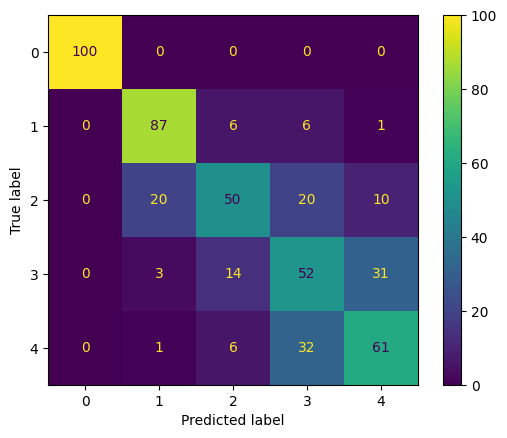

In [ ]:
cm = confusion_matrix(y_true, y_predicted)
ConfusionMatrixDisplay(cm).plot()
plt.show()